# Simulation Closed Loop PID with FF


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors
from datetime import datetime
import os
import package_Lab

from importlib import reload
package_Lab=reload(package_Lab)



from package_Lab import LL_RT, PID_RT,IMC_tuning, Margin, Controller
import package_Lab
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode


In [52]:

TSim = 3000
Ts = 0.5
N = int(TSim/Ts) + 1

MV0 = 50
DV0 = 50
PV0 = 54 #point de fonctionnement, trouver en faisant 50 50 sur le systeme
E0 = PV0 - MV0
#Paramètres 




#Second ordre
Kp = 0.3768941279826313
T1p = TLead1 = 187.1409297022807
T2p = TLead2 = 10.452990644869
theta_p =  13.137983829128451 

#Premier ordre
Kp_FOPDTOPT =  0.37720311160467174
T_FOPDTOPT =  188.30559411020332
theta_FOPDTOPT = 23.189177284051183

#Perturbation
Kd = 0.3241048096246215
T1d = Tlag1 = 221.16602071422838 
T2d = Tlag2 = 16.741635805529068
theta_d = 5.453465939559135


#C
gamma = 0.9

Ti_IMC,Td_IMC,Kc_IMC = IMC_tuning(Kp, T1p,T2p,theta_p,gamma)
alpha_IMC = 0.9
print('Kc = ',Kc_IMC)
print('Ti = ',Ti_IMC)
print('Td = ',Td_IMC)


# C = Controller({})



Kc =  2.887503384440852
Ti =  197.5939203471497
Td =  9.90001303690539


## Scénarios


In [ ]:
# #Scénario OLP sans FF
# SPPath = {0: PV0,TSim: PV0} 
# DVPath = {0: DV0, 2000: DV0+10, TSim: DV0+10} 
# MANPath = {0: True, 400: True, TSim: True} 
# MVMANPath = {0: MV0, TSim: MV0}
# StateFF = False
# ManFF =  False

# #Scénario OLP + FF
SPPath = {0: PV0,TSim: PV0} 
DVPath = {0: DV0, 2000: DV0+10, TSim: DV0+10} 
MANPath = {0: True, 400: True, TSim: True} 
MVMANPath = {0: MV0, TSim: MV0}
StateFF = True
ManFF =  True

# #Scénario CLP sans FF
# SPPath = {0: PV0+5, 1500: PV0-5, TSim: PV0-5} 
# DVPath = {0: DV0, 2000: DV0+10, TSim: DV0+10} 
# MANPath = {0: True, 400: False, TSim: False} 
# MVMANPath = {0: MV0+10, TSim: MV0+10}
# StateFF = False
# ManFF =  False

#Scénario CLP + FF
# SPPath = {0: PV0+5, 1500: PV0-5, TSim: PV0-5} 
# DVPath = {0: DV0, 2000: DV0+10, TSim: DV0+10} 
# MANPath = {0: True, 400: False, TSim: False} 
# MVMANPath = {0: MV0+10, TSim: MV0+10}
# StateFF = True
# ManFF =  False


In [54]:
MVMAx = 100 
MVMin = 0

t = []
PV= []
SP = []
MV = []
DV = []
MV_PID = []
MVI = []
MVP = []
MVD = []

MAN = []
MVMAN = []


E = []
PV1 = []


#FF
MANFF = []
MVFF = []
MVFFDelay = []

#P(s) Parameters

MVDelayp = []
PV1p = []
PV2p = []

#D(s) Parameters
MVDelayd = []
PV1d = []
PV2d = []

for i in range(0,N):
    t.append(i*Ts)
    
    SelectPath_RT(SPPath,t,SP)
    SelectPath_RT(DVPath,t,DV)
    SelectPath_RT(MANPath,t,MAN) 
    SelectPath_RT(MVMANPath,t,MVMAN) 
    
    #FF
    
    Delay_RT(DV - DV0*np.ones_like(DV), np.max([theta_d-theta_p,0]),Ts,MVFFDelay)
    LL_RT(MVFFDelay,-Kd/Kp,Tlag1,TLead1,Ts,PV1)

    if StateFF:
        LL_RT(PV1,1,Tlag2,TLead2,Ts,MVFF)
    else:
        LL_RT(PV1,0,Tlag2,TLead2,Ts,MVFF)       

    

    PID_RT(SP, PV,MAN,MVMAN, MVFF, Kc_IMC, Ti_IMC, Td_IMC, alpha_IMC, Ts, MVMin, MVMAx, MV, MVP, MVI, MVD, E, ManFF, PV0)

   

    #Input-output dynamics P(s)
    Delay_RT(MV,theta_p,Ts,MVDelayp,MV0)
    FO_RT(MVDelayp,Kp,T1p,Ts,PV1p,0) 
    FO_RT(PV1p,1,T2p,Ts,PV2p,0)

    #Disturbance dynamics D(s)
    Delay_RT(DV - DV0*np.ones_like(DV), theta_d,Ts,MVDelayd,0)
    FO_RT(MVDelayd,Kd,T1d,Ts,PV1d,0)
    FO_RT(PV1d,1,T2d,Ts,PV2d,0)

    PV.append(PV2p[-1] + PV2d[-1] + PV0 - Kp*MV0)

[0.0] initial MVI


## Plots


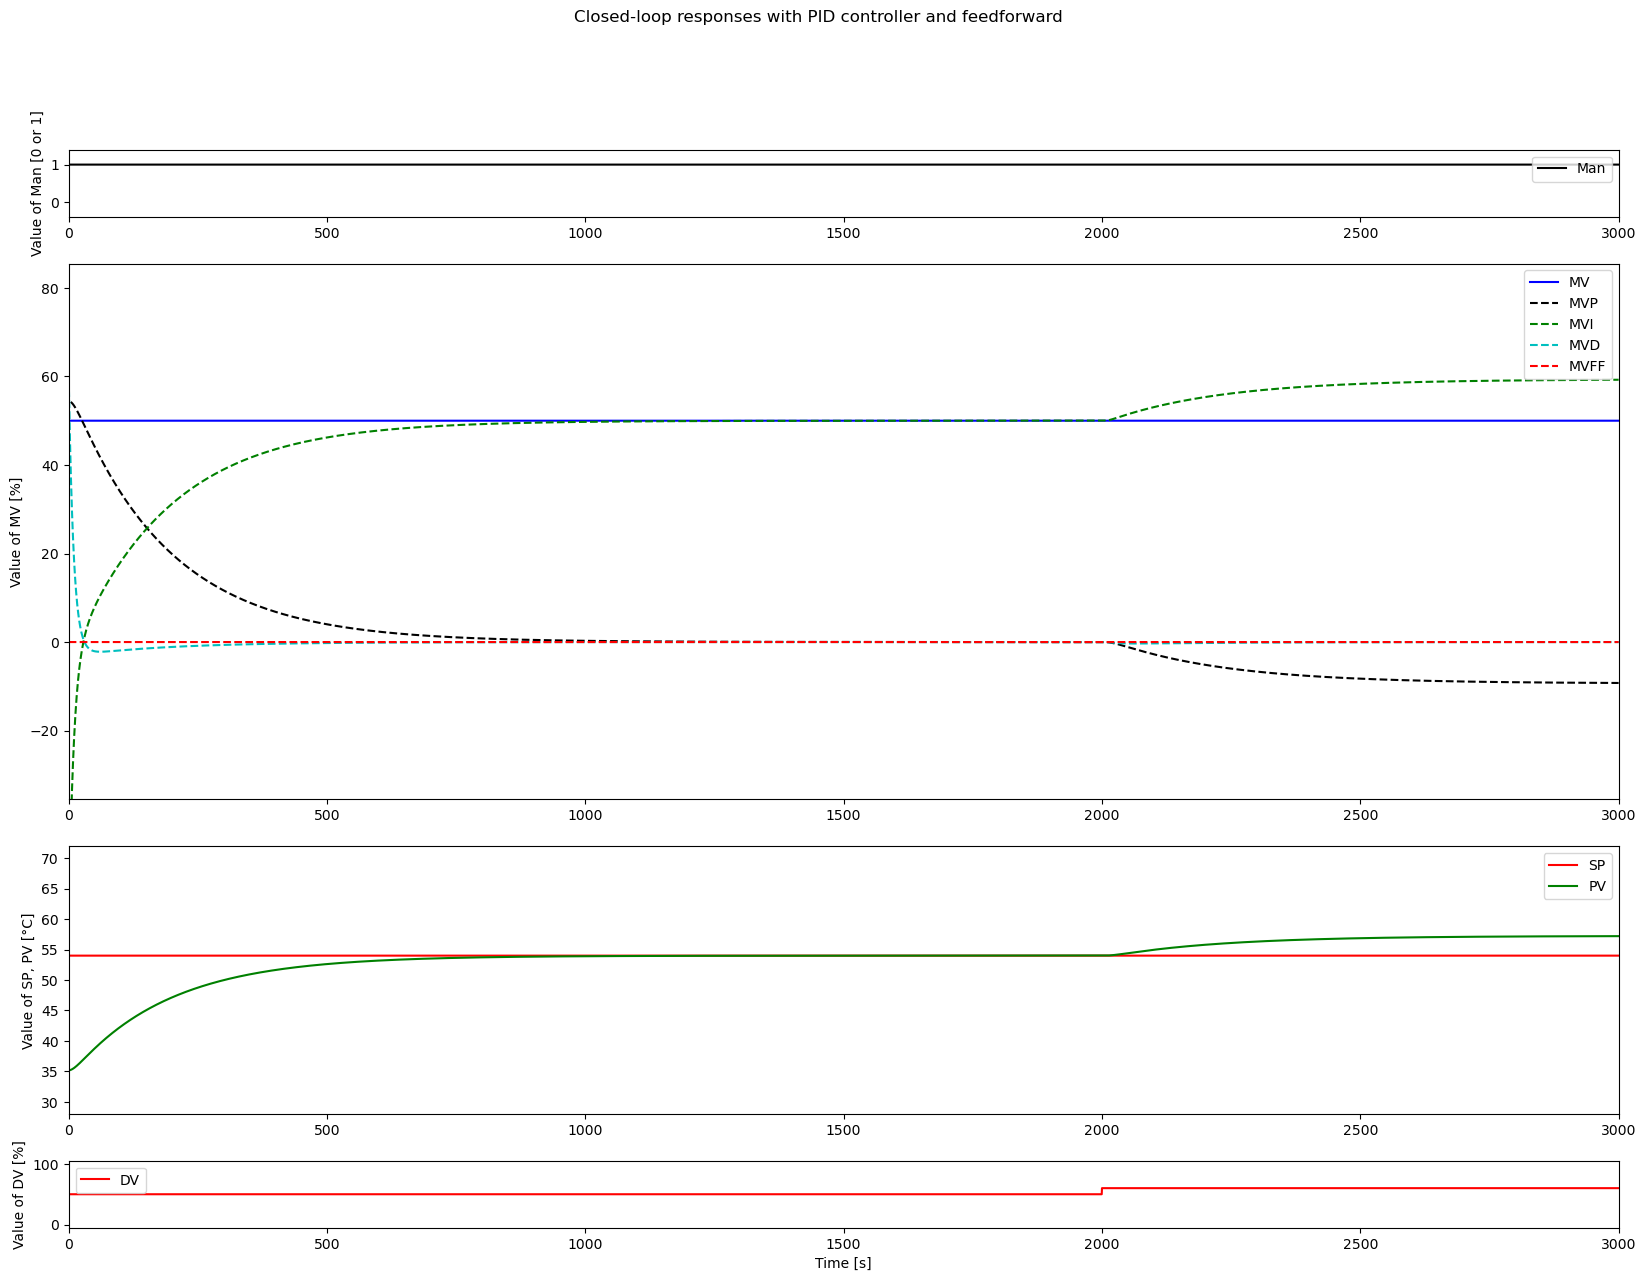

In [55]:
fig, (ax1,ax2,ax3,ax4) = plt.subplots(4, 1,figsize=(20, 14), gridspec_kw={'height_ratios': [1, 8, 4,1]})
fig.suptitle('Closed-loop responses with PID controller and feedforward')

#Manual Mode
MAN_int = [1 if m else 0 for m in MAN]
l1, = ax1.plot(t, MAN_int, 'k-', label='Man')
ax1.set_ylabel('Value of Man [0 or 1]')
ax1.set_ylim([-0.4, 1.4])
ax1.legend(loc='upper right')
ax1.set_xlim([0, TSim])

#MV
l2, = ax2.plot([0,TSim], [-30,80],   'b-', label='MV')
l3, = ax2.plot([0,TSim], [-30,80],  'k--', label='MVP')
l4, = ax2.plot([0,TSim], [-30,80],  'g--', label='MVI')
l5, = ax2.plot([0,TSim], [-30,80],  'c--', label='MVD')
l6, = ax2.plot([0,TSim], [-30,80], 'r--', label='MVFF')
ax2.set_ylabel('Value of MV [%]')
ax2.legend(loc='upper right')
ax2.set_xlim([0, TSim])

# SP, PV

l7, = ax3.plot([0,TSim], [30,70], 'r-', label='SP')
l8, = ax3.plot([0,TSim], [30,70], 'g-', label='PV')
ax3.set_ylabel('Value of SP, PV [°C]')
ax3.legend(loc='upper right')
ax3.set_xlim([0, TSim])

# DV


l9, = ax4.plot([0,TSim], [0,100], 'r-', label='DV')
ax4.set_ylabel('Value of DV [%]')

ax4.set_xlabel('Time [s]')
ax4.legend(loc='upper left')
ax4.set_xlim([0, TSim])


l1.set_data(t,MAN)

l2.set_data(t,MV)
l3.set_data(t,MVP)
l4.set_data(t,MVI)
l5.set_data(t,MVD)
l6.set_data(t,MVFF)

l7.set_data(t,SP)
l8.set_data(t,PV)

l9.set_data(t,DV)


plt.show()